In [20]:
#Primero de todo importamos las librerías necesarias para el proyecto

#Librerias para la creacion de los modelos
import tensorflow as tf
from tensorflow import keras
from keras import layers
from sklearn.preprocessing import MinMaxScaler

#Librerias para la carga de los datos
from ucimlrepo import fetch_ucirepo 

#Libreria para dibujar graficos
import matplotlib.pyplot as plt
#importamos np
import numpy as np


In [ ]:

#Ahora importamos nuestra capa creada que vamos a analizar en este proyecto siendo la que tiene el polinomio de Legendre

class PolynomialLegendre(tf.keras.layers.Layer):
    def __init__(self, units, degree=2, use_bias=True, **kwargs):
        super(PolynomialLegendre, self).__init__(**kwargs)
        self.units = units
        self.degree = degree
        self.use_bias = use_bias

    def build(self, input_shape):
        input_dim = input_shape[-1]
        # El kernel debe cubrir (grado + 1) si incluyes P0, o (grado) si empiezas en P1
        # Aquí usaremos desde P1 hasta P_degree
        self.kernel = self.add_weight(
            shape=(input_dim * self.degree, self.units),
            initializer=tf.keras.initializers.GlorotUniform(),
            trainable=True,
            name="kernel"
        )

        if self.use_bias:
            self.bias = self.add_weight(
                shape=(self.units,),
                initializer="zeros",
                trainable=True,
                name="bias"
            )

    def call(self, inputs):
        # Aseguramos que los inputs sean float32
        x = tf.cast(inputs, self.compute_dtype)
        
        # P0 = 1, P1 = x
        p_nm2 = tf.ones_like(x)
        p_nm1 = x
        
        features = [p_nm1] # Empezamos con grado 1

        for n in range(2, self.degree + 1):
            n_float = tf.cast(n, self.compute_dtype)
            # Fórmula de recurrencia de Legendre
            p_n = ((2.0 * n_float - 1.0) * x * p_nm1 - (n_float - 1.0) * p_nm2) / n_float
            features.append(p_n)
            
            p_nm2 = p_nm1
            p_nm1 = p_n

        # Concatenamos: (batch, input_dim * degree)
        # Esto genera: [x_poly1, x_poly2, ..., x_poly_degree]
        phi = tf.concat(features, axis=-1)

        output = tf.matmul(phi, self.kernel)

        if self.use_bias:
            output = tf.nn.bias_add(output, self.bias)

        return output
    


In [22]:
def plot_cv_average_history(histories):
    # Encontrar la duración máxima de los entrenamientos
    max_epochs = max([len(h.history['loss']) for h in histories])
    epochs = np.arange(1, max_epochs + 1)

    # Función interna para rellenar con NaNs y poder promediar
    def get_padded_metrics(metric_name):
        matrix = np.full((len(histories), max_epochs), np.nan)
        for i, h in enumerate(histories):
            data = h.history[metric_name]
            matrix[i, :len(data)] = data
        return np.nanmean(matrix, axis=0)

    # Calculamos promedios
    avg_loss = get_padded_metrics('loss')
    avg_val_loss = get_padded_metrics('val_loss')
    avg_acc = get_padded_metrics('accuracy')
    avg_val_acc = get_padded_metrics('val_accuracy')

    plt.figure(figsize=(14, 6))

    # --- Gráfica de Pérdida Promedio ---
    plt.subplot(1, 2, 1)
    plt.plot(epochs, avg_loss, label='Promedio Entrenamiento', color='blue', linewidth=2)
    plt.plot(epochs, avg_val_loss, label='Promedio Validación', color='orange', linewidth=2)
    plt.title('Pérdida Promedio (Cross-Validation)')
    plt.xlabel('Épocas')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # --- Gráfica de Precisión Promedio ---
    plt.subplot(1, 2, 2)
    plt.plot(epochs, avg_acc, label='Promedio Entrenamiento', color='blue', linewidth=2)
    plt.plot(epochs, avg_val_acc, label='Promedio Validación', color='orange', linewidth=2)
    plt.title('Precisión Promedio (Cross-Validation)')
    plt.xlabel('Épocas')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [23]:
#Cargamos los datos del Dataset.
# fetch dataset 
magic_gamma_telescope = fetch_ucirepo(id=159) 
  
X = magic_gamma_telescope.data.features 
y = magic_gamma_telescope.data.targets 

In [24]:
#parametros para el entrenamiento
epochs = 200
batch_size = 32
input_dim = X.shape[1]
num_splits = 10

In [ ]:
def PolynomialDenseCreator(degree):
    inputPoli = keras.Input(shape=(input_dim,))
    x = PolynomialLegendre(32, degree=degree)(inputPoli)
    x = layers.Activation('swish')(x)
    x = layers.Dense(16, activation='swish')(x)
    outputPoli = layers.Dense(2, activation='softmax')(x)
    
    model = keras.Model(inputs=inputPoli, outputs=outputPoli, name=f"Polynomial_Model_Degree_{degree}")
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [26]:
from sklearn.model_selection import StratifiedKFold
from tqdm import tqdm

skf = StratifiedKFold(n_splits=num_splits, shuffle=True, random_state=1)
#Conjunto de datos para luego poder luego ver el entrenamiento de cada modelo y su evolución a lo largo de las épocas
fitHistory2,fitHistory3,fitHistory4 = [],[],[]
#Guardar los scores de cada modelo para luego poder compararlos
scores2, scores3, scores4 = [], [], []


X = X.to_numpy()
y = y.to_numpy()

for train_index, test_index in tqdm(skf.split(X, y), total=num_splits):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Normalizamos los datos
    scaler = MinMaxScaler(feature_range=(-1, 1))
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Cambiamos las etiquetas a 0 y 1
    y_train = (y_train == 'g').astype(int)
    y_test = (y_test == 'g').astype(int)

    model_poli2 = PolynomialDenseCreator(degree=2)
    model_poli3 = PolynomialDenseCreator(degree=3)
    model_poli4 = PolynomialDenseCreator(degree=4)

    # Entrenamos los modelos con Early Stopping
    history_poli2 = model_poli2.fit(X_train_scaled, y_train, validation_split=0.2, epochs=epochs, batch_size=32, verbose=0)
    history_poli3 = model_poli3.fit(X_train_scaled, y_train, validation_split=0.2, epochs=epochs, batch_size=32, verbose=0)
    history_poli4 = model_poli4.fit(X_train_scaled, y_train, validation_split=0.2, epochs=epochs, batch_size=32, verbose=0)

    fitHistory2.append(history_poli2)
    fitHistory3.append(history_poli3)
    fitHistory4.append(history_poli4)

    # Evaluamos los modelos
    scores2.append(model_poli2.evaluate(X_test_scaled, y_test, verbose=0))
    scores3.append(model_poli3.evaluate(X_test_scaled, y_test, verbose=0))
    scores4.append(model_poli4.evaluate(X_test_scaled, y_test, verbose=0))

  0%|          | 0/10 [00:04<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
def calculator(scores):
    Totalloss, Totalaccuracy = 0, 0
    for loss, accuracy in scores:
        Totalloss += loss
        Totalaccuracy += accuracy

    return Totalloss/num_splits, Totalaccuracy/num_splits

In [ ]:
results2 = calculator(scores2)
results3 = calculator(scores3)
results4 = calculator(scores4)

#Imprimimos los resultados finales
print("\n" + "="*40)
print("  RESULTADOS FINALES (Promedio CV)")
print("="*40)
print(f"Grado 2 - Pérdida Promedio: {results2[0]:.4f}, Accuracy Promedio: {results2[1]:.4f}")
print(f"Grado 3 - Pérdida Promedio: {results3[0]:.4f}, Accuracy Promedio: {results3[1]:.4f}")
print(f"Grado 4 - Pérdida Promedio: {results4[0]:.4f}, Accuracy Promedio: {results4[1]:.4f}")


  RESULTADOS FINALES (Promedio CV)
Grado 2 - Pérdida Promedio: 0.3366, Accuracy Promedio: 0.8679
Grado 3 - Pérdida Promedio: 0.3488, Accuracy Promedio: 0.8690
Grado 4 - Pérdida Promedio: 0.3613, Accuracy Promedio: 0.8694


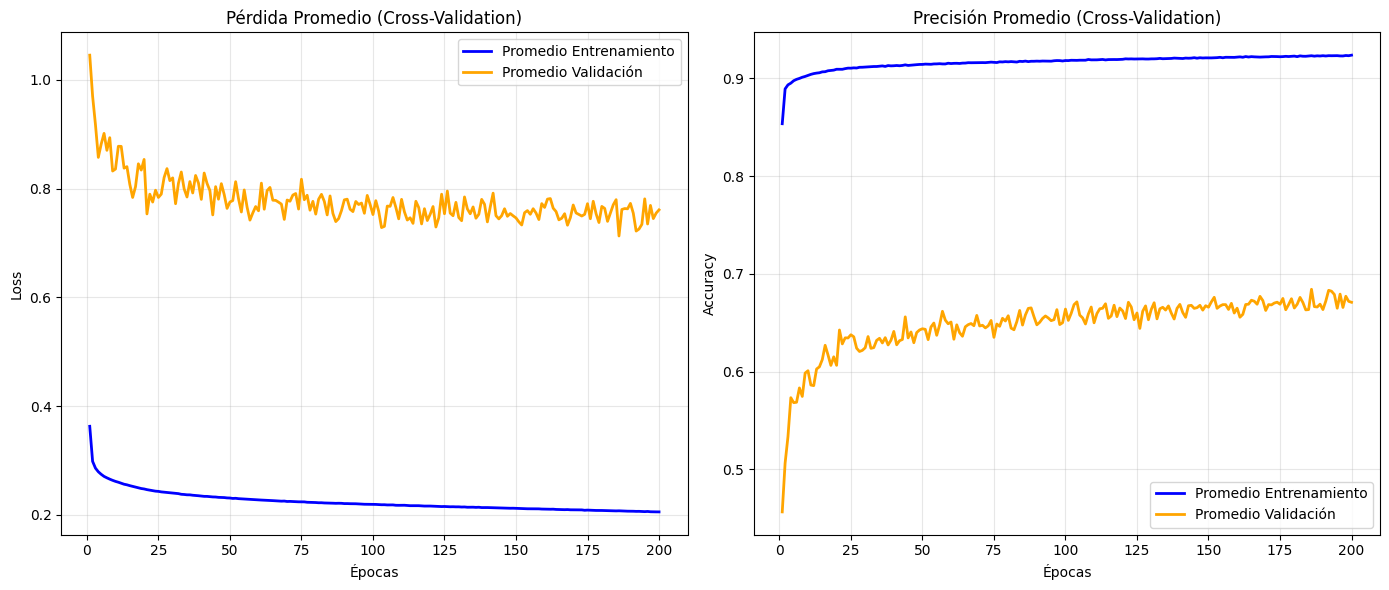

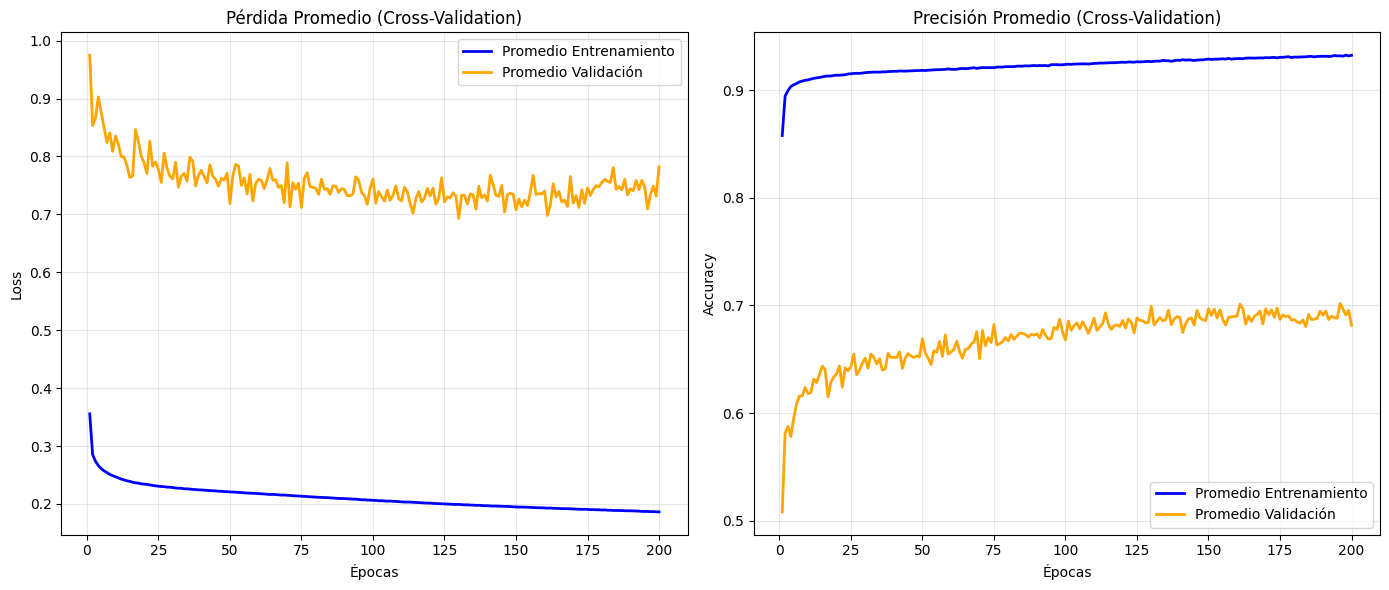

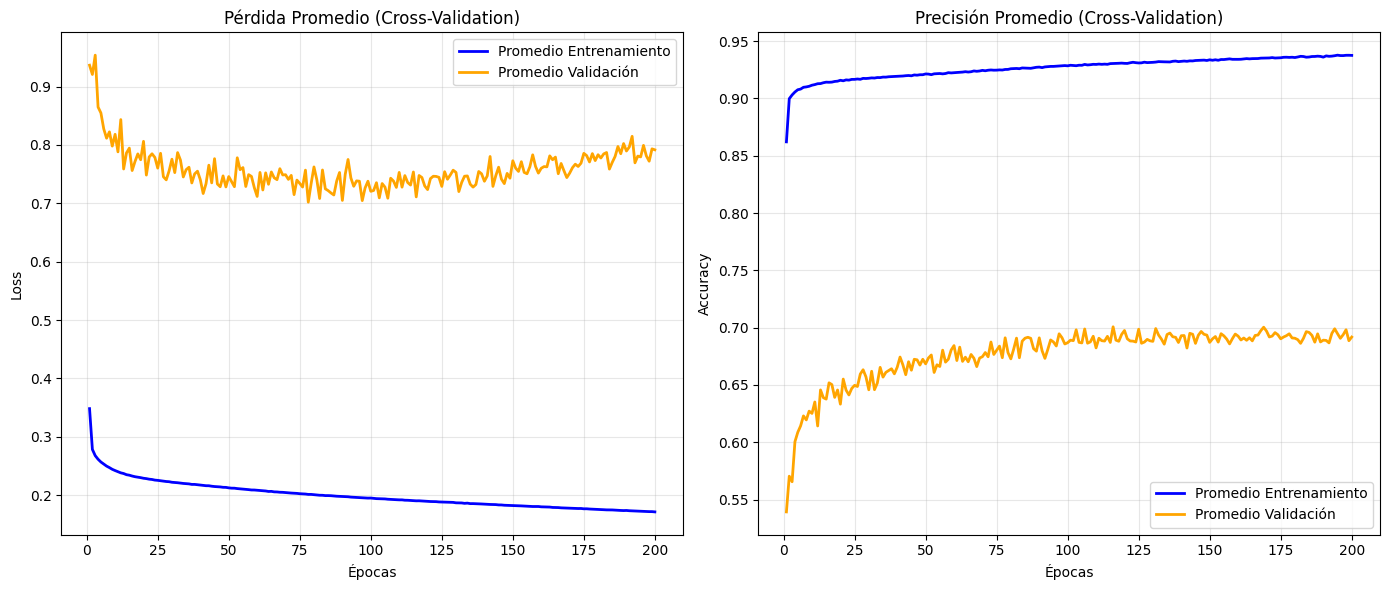

In [ ]:
#Imrimimos las graficas de la evolución del entrenamiento de cada modelo
plot_cv_average_history(fitHistory2)
plot_cv_average_history(fitHistory3)
plot_cv_average_history(fitHistory4)

## Con solamente un grado

In [52]:
#Primero de todo importamos las librerías necesarias para el proyecto

#Librerias para la creacion de los modelos
import tensorflow as tf
from tensorflow import keras
from keras import layers
from sklearn.preprocessing import MinMaxScaler

#Librerias para la carga de los datos
from ucimlrepo import fetch_ucirepo 

#Libreria para dibujar graficos
import matplotlib.pyplot as plt
#importamos np
import numpy as np


In [53]:
#Ahora importamos nuestra capa creada que vamos a analizar en este proyecto siendo la que tiene el polinomio de Lagrange

class PolynomialDense2(tf.keras.layers.Layer):
    def __init__(self, units, degree=2, use_bias=True, **kwargs):
        super(PolynomialDense2, self).__init__(**kwargs)
        self.units = units
        self.degree = degree
        self.use_bias = use_bias

    def build(self, input_shape):
        input_dim = input_shape[-1]
        # El kernel debe cubrir (grado + 1) si incluyes P0, o (grado) si empiezas en P1
        # Aquí usaremos desde P1 hasta P_degree
        self.kernel = self.add_weight(
            shape=(input_dim * self.degree, self.units),
            initializer=tf.keras.initializers.GlorotUniform(),
            trainable=True,
            name="kernel"
        )

        if self.use_bias:
            self.bias = self.add_weight(
                shape=(self.units,),
                initializer="zeros",
                trainable=True,
                name="bias"
            )

    def call(self, inputs):
        # Aseguramos que los inputs sean float32
        x = tf.cast(inputs, self.compute_dtype)
        
        # P0 = 1, P1 = x
        p_nm2 = tf.ones_like(x)
        p_nm1 = x
        
        features = [p_nm1] # Empezamos con grado 1

        for n in range(2, self.degree + 1):
            n_float = tf.cast(n, self.compute_dtype)
            # Fórmula de recurrencia de Legendre
            p_n = ((2.0 * n_float - 1.0) * x * p_nm1 - (n_float - 1.0) * p_nm2) / n_float
            features.append(p_n)
            
            p_nm2 = p_nm1
            p_nm1 = p_n

        # Concatenamos: (batch, input_dim * degree)
        # Esto genera: [x_poly1, x_poly2, ..., x_poly_degree]
        phi = tf.concat(features, axis=-1)

        output = tf.matmul(phi, self.kernel)

        if self.use_bias:
            output = tf.nn.bias_add(output, self.bias)

        return output

In [54]:
def plot_cv_average_history(histories):
    # Encontrar la duración máxima de los entrenamientos
    max_epochs = max([len(h.history['loss']) for h in histories])
    epochs = np.arange(1, max_epochs + 1)

    # Función interna para rellenar con NaNs y poder promediar
    def get_padded_metrics(metric_name):
        matrix = np.full((len(histories), max_epochs), np.nan)
        for i, h in enumerate(histories):
            data = h.history[metric_name]
            matrix[i, :len(data)] = data
        return np.nanmean(matrix, axis=0)

    # Calculamos promedios
    avg_loss = get_padded_metrics('loss')
    avg_val_loss = get_padded_metrics('val_loss')
    avg_acc = get_padded_metrics('accuracy')
    avg_val_acc = get_padded_metrics('val_accuracy')

    plt.figure(figsize=(14, 6))

    # --- Gráfica de Pérdida Promedio ---
    plt.subplot(1, 2, 1)
    plt.plot(epochs, avg_loss, label='Promedio Entrenamiento', color='blue', linewidth=2)
    plt.plot(epochs, avg_val_loss, label='Promedio Validación', color='orange', linewidth=2)
    plt.title('Pérdida Promedio (Cross-Validation)')
    plt.xlabel('Épocas')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # --- Gráfica de Precisión Promedio ---
    plt.subplot(1, 2, 2)
    plt.plot(epochs, avg_acc, label='Promedio Entrenamiento', color='blue', linewidth=2)
    plt.plot(epochs, avg_val_acc, label='Promedio Validación', color='orange', linewidth=2)
    plt.title('Precisión Promedio (Cross-Validation)')
    plt.xlabel('Épocas')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [55]:
#Cargamos los datos del Dataset.
# fetch dataset 
magic_gamma_telescope = fetch_ucirepo(id=159) 
  
X = magic_gamma_telescope.data.features 
y = magic_gamma_telescope.data.targets 

input_dim = X.shape[1]

batch_size = 32
def PolynomialDenseCreator(degree):
    inputPoli = keras.Input(shape=(input_dim,))
    x = PolynomialDense2(32, degree=degree)(inputPoli)
    x = layers.Activation('swish')(x)
    x = layers.Dense(16, activation='swish')(x)
    outputPoli = layers.Dense(2, activation='softmax')(x)
    
    model = keras.Model(inputs=inputPoli, outputs=outputPoli, name=f"Polynomial_Model_Degree_{degree}")
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [56]:
#early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

In [57]:
from sklearn.model_selection import StratifiedKFold
from tqdm import tqdm

#Parametros para el entrenamiento
degree = 3
num_splits = 10
epochs = 120

skf = StratifiedKFold(n_splits=num_splits, shuffle=True, random_state=1)
score = []
history = []

X = X.to_numpy()
y = y.to_numpy()

for train_index, test_index in tqdm(skf.split(X, y), total=num_splits):
    #Reseteanis el estado de Keras para cada iteración
    tf.keras.backend.clear_session()
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Normalizamos los datos
    scaler = MinMaxScaler(feature_range=(-1, 1))
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Cambiamos las etiquetas a 0 y 1
    y_train = (y_train == 'g').astype(int)
    y_test = (y_test == 'g').astype(int)

    model = PolynomialDenseCreator(degree)
    his = model.fit(X_train_scaled, y_train, validation_split=0.2, epochs=epochs, batch_size=32, verbose=0)

    score.append(model.evaluate(X_test_scaled, y_test, verbose=0))
    history.append(his)

100%|██████████| 10/10 [11:32<00:00, 69.23s/it]


Grado 3 - Pérdida Promedio: 0.3372, Precisión Promedio: 0.8688


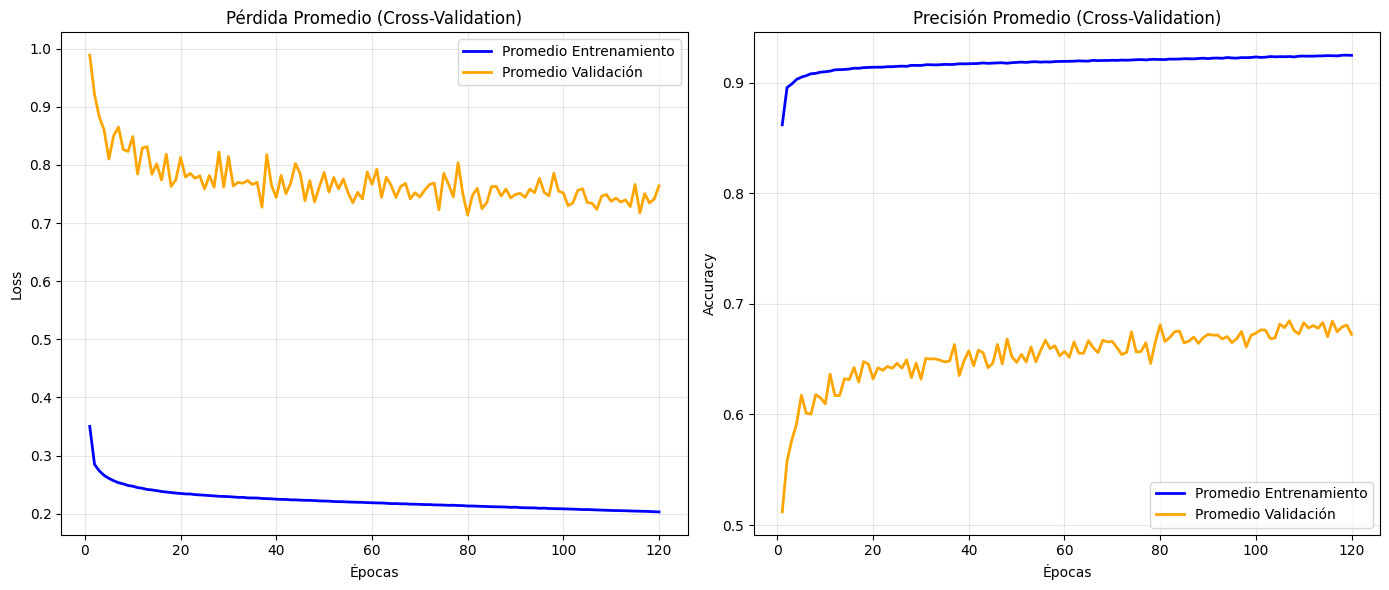

In [60]:
Totalloss, Totalaccuracy = 0, 0
for loss, accuracy in score:
    Totalloss += loss
    Totalaccuracy += accuracy

print(f"Grado {degree} - Pérdida Promedio: {Totalloss/num_splits:.4f}, Precisión Promedio: {Totalaccuracy/num_splits:.4f}")
plot_cv_average_history(history)

In [61]:
#Miramos  cuantas epocas ha durado el entrenamiento de cada modelo para ver la evolución de la pérdida y precisión a lo largo de las épocas
for i, hist in enumerate(history):
    print(f"Modelo {i+1} - Épocas entrenadas: {len(hist.history['loss'])}")

Modelo 1 - Épocas entrenadas: 120
Modelo 2 - Épocas entrenadas: 120
Modelo 3 - Épocas entrenadas: 120
Modelo 4 - Épocas entrenadas: 120
Modelo 5 - Épocas entrenadas: 120
Modelo 6 - Épocas entrenadas: 120
Modelo 7 - Épocas entrenadas: 120
Modelo 8 - Épocas entrenadas: 120
Modelo 9 - Épocas entrenadas: 120
Modelo 10 - Épocas entrenadas: 120
